# AP1 — Análise exploratória do preço de venda de imóveis residenciais


## Contexto

A base reúne informações sobre imóveis residenciais, seus preços de venda e suas características. Antes de calcular probabilidades ou ajustar modelos, é necessário conhecer a estrutura, a qualidade e o comportamento dos dados.


## Pergunta de pesquisa

Como se distribuem e variam os preços de venda de imóveis residenciais?


## Objetivo da investigação

Caracterizar a distribuição e a variabilidade dos preços de venda e investigar suas relações com características físicas, qualitativas e temporais dos imóveis.


## Dados e característica atribuída

O grupo utilizará o arquivo bruto fornecido pelo professor, conforme a especificação geral. O professor atribuirá uma característica qualitativa $B$ diferente a cada grupo, mas não fornecerá uma base preparada nem classificará previamente os valores ausentes.


## Carregamento dos dados

Uma célula de código exclusiva deverá carregar `data/raw/AmesHousing.txt`. A cópia bruta será preservada sem alterações. Caminho, procedimento de leitura, dimensões, unidade de análise e inspeção inicial deverão aparecer em etapas separadas.


## Etapas obrigatórias

O conjunto mínimo será composto por seis tabelas ou resumos tabulares e seis figuras. Figuras com dois painéis contarão como uma figura. Não deverão ser acrescentadas visualizações que apenas repitam a mesma informação sem nova finalidade analítica.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

caminho_bruto = "data/raw/AmesHousing.csv"
df = pd.read_csv(caminho_bruto, sep=",", encoding="utf-8")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


### 1. Importação e rastreabilidade

- Registrar a identificação e a procedência do arquivo fornecido.
- Importar o arquivo bruto sem alterar a cópia armazenada em `data/raw/`.
- Verificar separador, codificação, dimensões e unidade de análise.
- Identificar os nomes originais das variáveis necessárias.
- Documentar eventual normalização dos nomes.
- Apresentar o nome legível de cada variável seguido do nome original entre parênteses.


In [2]:
# Verificação do separador e da codificação a partir da linha bruta do arquivo (df permanece intacto).
with open(caminho_bruto, "r", encoding="utf-8") as f:
    primeira_linha = f.readline()
print("Separador identificado: ',' | Codificação: utf-8")
print(f"Cabeçalho bruto (trecho): {primeira_linha[:100]}...")

# Dimensões e unidade de análise reafirmadas.
print(f"Dimensões confirmadas: {df.shape[0]} linhas x {df.shape[1]} colunas")
print("Unidade de análise: um imóvel residencial vendido por registro (chave: PID).")

# Nomes originais das variáveis necessárias à investigação.
nomes_originais = [
    "SalePrice",
    "Gr Liv Area",
    "Garage Finish",
    "Yr Sold",
    "Mo Sold",
    "Fireplaces",
    "Mas Vnr Area",
    "Year Remod/Add",
    "Year Built",
]
print("Presentes na base:", [c for c in nomes_originais if c in df.columns])

# Normalização documentada: mapeamento de nome legível para nome original (sem alterar df).
mapa_nomes = {
    "preco_venda": "SalePrice",
    "area_construida": "Gr Liv Area",
    "acabamento_garagem": "Garage Finish",
    "ano_venda": "Yr Sold",
    "mes_venda": "Mo Sold",
    "lareiras": "Fireplaces",
    "area_revestimento_alvenaria": "Mas Vnr Area",
    "ano_reforma": "Year Remod/Add",
    "ano_construcao": "Year Built",
}

# Tabela 1 - nome legível seguido do nome original entre parênteses.
tabela_nomes = pd.DataFrame(
    {
        "nome_legivel": list(mapa_nomes.keys()),
        "nome_original": list(mapa_nomes.values()),
    }
)
tabela_nomes["variavel"] = (
    tabela_nomes["nome_legivel"] + " (" + tabela_nomes["nome_original"] + ")"
)
tabela_nomes

Separador identificado: ',' | Codificação: utf-8
Cabeçalho bruto (trecho): Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...
Dimensões confirmadas: 2930 linhas x 82 colunas
Unidade de análise: um imóvel residencial vendido por registro (chave: PID).
Presentes na base: ['SalePrice', 'Gr Liv Area', 'Garage Finish', 'Yr Sold', 'Mo Sold', 'Fireplaces', 'Mas Vnr Area', 'Year Remod/Add', 'Year Built']


,nome_legivel,nome_original,variavel
0,preco_venda,SalePrice,preco_venda (SalePrice)
1,area_construida,Gr Liv Area,area_construida (Gr Liv Area)
2,acabamento_garagem,Garage Finish,acabamento_garagem (Garage Finish)
3,ano_venda,Yr Sold,ano_venda (Yr Sold)
4,mes_venda,Mo Sold,mes_venda (Mo Sold)
5,lareiras,Fireplaces,lareiras (Fireplaces)
6,area_revestimento_alvenaria,Mas Vnr Area,area_revestimento_alvenaria (Mas Vnr Area)
7,ano_reforma,Year Remod/Add,ano_reforma (Year Remod/Add)
8,ano_construcao,Year Built,ano_construcao (Year Built)


### 2. Qualidade e preparação

- Inspecionar tipos de dados.
- Identificar conversões necessárias.
- Investigar duplicidades e valores ausentes.
- Consultar a documentação para interpretar os códigos encontrados.
- Justificar cada tratamento.
- Preservar uma cópia lógica dos dados originais.
- Apresentar um resumo tabular dos tipos, valores ausentes e duplicidades.
- Inspecionar e documentar as colunas `Fireplaces`, `Mas Vnr Area`, `Year Remod/Add` e `Year Built`, necessárias à trilha Binomial da AP2 e, quando corresponderem à característica $B$, à modelagem da AP3.
- Não classificar automaticamente valores ausentes de `Mas Vnr Area` como ausência de revestimento; preservar ou tratar esses valores com justificativa documentada.


In [3]:
# Cópia lógica dos dados brutos para preparação; df permanece inalterado.
dados = df.copy()

# Inspeção dos tipos computacionais atuais.
display(dados.dtypes)

# Tabela 2 - resumo de tipos, ausências e duplicidades por coluna (15 com mais ausências).
resumo_qualidade = pd.DataFrame(
    {
        "tipo": dados.dtypes.astype(str),
        "n_ausentes": dados.isna().sum(),
        "proporcao_ausente_%": (dados.isna().mean() * 100).round(2),
    }
).sort_values("n_ausentes", ascending=False)
display(resumo_qualidade.head(15))

# Duplicidades: linhas integrais e repetição da chave da unidade de análise (PID).
print(f"Duplicatas integrais: {dados.duplicated().sum()}")
print(f"Duplicatas de PID: {dados['PID'].duplicated().sum()}")

# Inspeção dedicada das colunas exigidas pela trilha Binomial da AP2 / modelagem da AP3.
colunas_criticas = ["Fireplaces", "Mas Vnr Area", "Year Remod/Add", "Year Built"]
display(dados[colunas_criticas].dtypes)
display(dados[colunas_criticas].isna().sum())
display(dados[colunas_criticas].describe())

# Documentação dos códigos (dicionário de dados Ames Housing):
# - Fireplaces: contagem inteira de lareiras (int64), sem ausências; tipo mantido.
# - Year Built e Year Remod/Add: ano de construção e de reforma (int64), sem ausências; mantidos como
#   inteiros, pois representam apenas o ano (sem dia/mês) e não exigem dtype de data.
# - Mas Vnr Area: área de revestimento em alvenaria, em pés². A maioria dos registros com
#   Mas Vnr Type ausente tem Mas Vnr Area = 0 (documentado como "sem revestimento"); os casos abaixo
#   têm AMBOS ausentes e não podem ser distinguidos entre "sem revestimento" e falha de coleta.
print(f"Mas Vnr Area ausente: {dados['Mas Vnr Area'].isna().sum()} casos")
print(
    f"Mas Vnr Type ausente com Mas Vnr Area preenchida (interpretado como 'sem revestimento'): "
    f"{(dados['Mas Vnr Type'].isna() & dados['Mas Vnr Area'].notna()).sum()} casos"
)
display(dados.loc[dados["Mas Vnr Area"].isna(), "Mas Vnr Type"])

# Tratamento: os valores ausentes de Mas Vnr Area NÃO serão convertidos para 0 nem para "sem revestimento";
# permanecem ausentes, preservando a distinção entre "sem revestimento documentado" (área = 0) e "não coletado".

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object

,tipo,n_ausentes,proporcao_ausente_%
Pool QC,str,2917,99.56
Misc Feature,str,2824,96.38
Alley,str,2732,93.24
Fence,str,2358,80.48
Mas Vnr Type,str,1775,60.58
Fireplace Qu,str,1422,48.53
Lot Frontage,float64,490,16.72
Garage Qual,str,159,5.43
Garage Yr Blt,float64,159,5.43
Garage Cond,str,159,5.43


Duplicatas integrais: 0
Duplicatas de PID: 0


Fireplaces          int64
Mas Vnr Area      float64
Year Remod/Add      int64
Year Built          int64
dtype: object

Fireplaces         0
Mas Vnr Area      23
Year Remod/Add     0
Year Built         0
dtype: int64

,Fireplaces,Mas Vnr Area,Year Remod/Add,Year Built
count,2930.000000,2907.000000,2930.000000,2930.000000
mean,0.599317,101.896801,1984.266553,1971.356314
std,0.647921,179.112611,20.860286,30.245361
min,0.000000,0.000000,1950.000000,1872.000000
25%,0.000000,0.000000,1965.000000,1954.000000
50%,1.000000,0.000000,1993.000000,1973.000000
75%,1.000000,164.000000,2004.000000,2001.000000
max,4.000000,1600.000000,2010.000000,2010.000000


Mas Vnr Area ausente: 23 casos
Mas Vnr Type ausente com Mas Vnr Area preenchida (interpretado como 'sem revestimento'): 1752 casos


55      NaN
484     NaN
517     NaN
538     NaN
867     NaN
1095    NaN
1119    NaN
1122    NaN
1127    NaN
1184    NaN
1454    NaN
1727    NaN
1751    NaN
1783    NaN
1799    NaN
1839    NaN
1840    NaN
2229    NaN
2260    NaN
2382    NaN
2392    NaN
2455    NaN
2823    NaN
Name: Mas Vnr Type, dtype: str

### 3. Análise univariada

Analisar:

- preço de venda (`SalePrice`);
- área construída (`Gr Liv Area`);
- característica qualitativa $B$, identificada por seu nome legível e pelo nome original atribuído.

Para preço de venda (`SalePrice`) e área construída (`Gr Liv Area`):

- apresentar, em uma mesma tabela, medidas de posição, dispersão e forma;
- construir histogramas em dois painéis da mesma figura;
- explicitar nos eixos as variáveis e suas unidades.

Para a característica qualitativa $B$:

- apresentar uma tabela de frequências absolutas e relativas;
- construir um gráfico de barras;
- preservar no título ou na legenda o nome legível e o nome original.


,n,media,mediana,desvio_padrao,minimo,Q1,Q3,maximo,assimetria,curtose
preco_venda (SalePrice),2930.0,180796.060068,160000.0,79886.692357,12789.0,129500.0,213500.00,755000.0,1.74350,5.118900
area_construida (Gr Liv Area),2930.0,1499.690444,1442.0,505.508887,334.0,1126.0,1742.75,5642.0,1.27411,4.137838


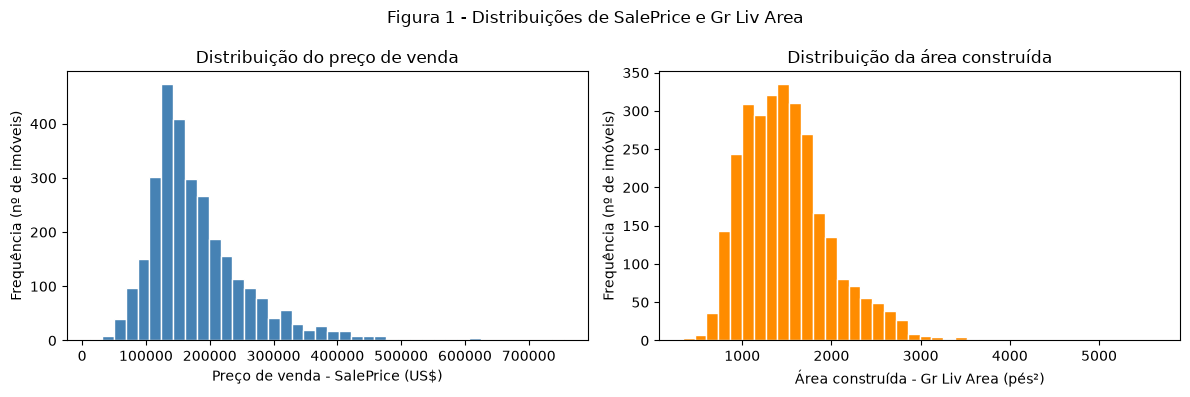

,freq_absoluta,freq_relativa_%
Garage Finish,,
Unf,1231,42.01
RFn,812,27.71
Fin,728,24.85
NaN,159,5.43


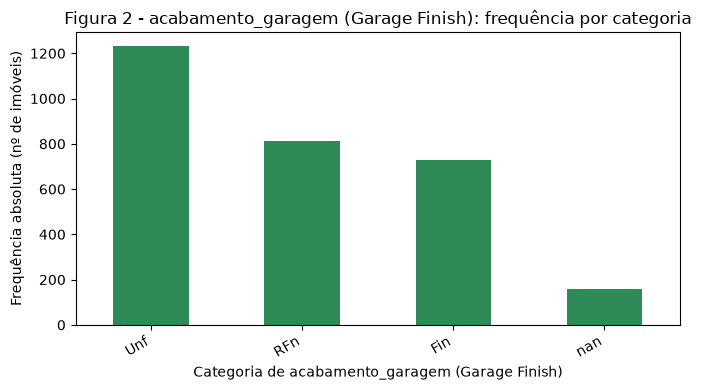

In [4]:
# Tabela 3 - medidas de posição, dispersão e forma para preco_venda e area_construida.
variaveis_quant = {
    "preco_venda (SalePrice)": dados["SalePrice"],
    "area_construida (Gr Liv Area)": dados["Gr Liv Area"],
}

# Para cada variável, calcula um conjunto de estatísticas e guarda o resultado em "linhas".
linhas = {}
for nome, s in variaveis_quant.items():
    estatisticas = {
        "n": s.count(),
        "media": s.mean(),
        "mediana": s.median(),
        "desvio_padrao": s.std(),
        "minimo": s.min(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "maximo": s.max(),
        "assimetria": s.skew(),
        "curtose": s.kurt(),
    }
    linhas[nome] = estatisticas

resumo_univariado = pd.DataFrame(linhas).T
display(resumo_univariado)

# Figura 1 - histogramas de preco_venda e area_construida em dois painéis.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dados["SalePrice"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Preço de venda - SalePrice (US$)")
axes[0].set_ylabel("Frequência (nº de imóveis)")
axes[0].set_title("Distribuição do preço de venda")

axes[1].hist(dados["Gr Liv Area"], bins=40, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Área construída - Gr Liv Area (pés²)")
axes[1].set_ylabel("Frequência (nº de imóveis)")
axes[1].set_title("Distribuição da área construída")

fig.suptitle("Figura 1 - Distribuições de SalePrice e Gr Liv Area")
fig.tight_layout()
plt.show()

# Tabela 4 - frequências absolutas e relativas da característica qualitativa B: acabamento_garagem (Garage Finish).
freq_b = dados["Garage Finish"].value_counts(dropna=False)
freq_rel_b = (
    dados["Garage Finish"].value_counts(normalize=True, dropna=False) * 100
).round(2)
tabela_b = pd.DataFrame({"freq_absoluta": freq_b, "freq_relativa_%": freq_rel_b})
display(tabela_b)

# Figura 2 - gráfico de barras de acabamento_garagem (Garage Finish).
fig, ax = plt.subplots(figsize=(7, 4))
tabela_b["freq_absoluta"].sort_values(ascending=False).plot(
    kind="bar", color="seagreen", ax=ax
)
ax.set_xlabel("Categoria de acabamento_garagem (Garage Finish)")
ax.set_ylabel("Frequência absoluta (nº de imóveis)")
ax.set_title("Figura 2 - acabamento_garagem (Garage Finish): frequência por categoria")
plt.xticks(rotation=30, ha="right")
fig.tight_layout()
plt.show()

### 4. Valores discrepantes

Aplicar obrigatoriamente as cercas de Tukey às variáveis quantitativas selecionadas:

$$
LI=Q_1-1{,}5\,IQR
\quad\text{e}\quad
LS=Q_3+1{,}5\,IQR,
\tag{1.1}
$$

em que $IQR=Q_3-Q_1$.

Apresentar uma tabela com $Q_1$, $Q_3$, $IQR$, limite inferior, limite superior e quantidade de casos sinalizados para preço de venda (`SalePrice`) e área construída (`Gr Liv Area`). Construir os respectivos boxplots em dois painéis da mesma figura.

Os valores sinalizados deverão ser investigados. O grupo decidirá entre manter, corrigir ou excluir, com justificativa contextual. Não será aceita remoção automática. Eventual exclusão deverá ser acompanhada de comparação com os resultados obtidos sem exclusão.


,Q1,Q3,IQR,limite_inferior,limite_superior,n_sinalizados
preco_venda (SalePrice),129500.0,213500.00,84000.00,3500.000,339500.000,137.0
area_construida (Gr Liv Area),1126.0,1742.75,616.75,200.875,2667.875,75.0


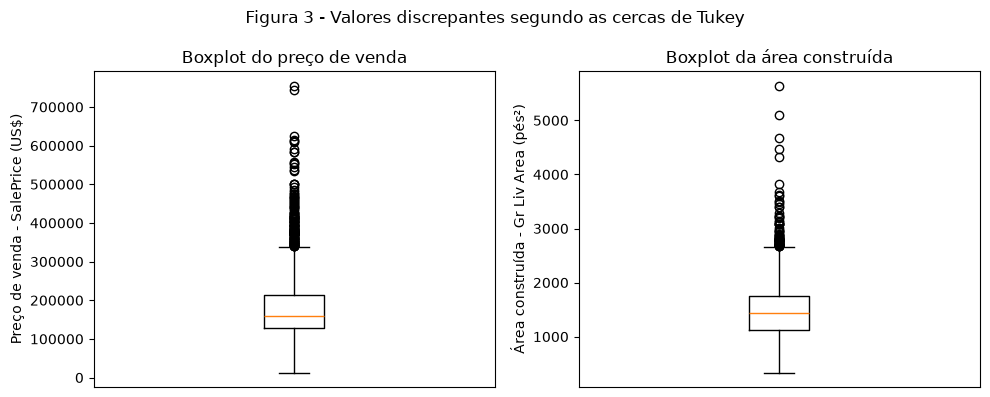

,Gr Liv Area,SalePrice,Sale Condition,Bldg Type
1498,5642,160000,Partial,1Fam
2180,5095,183850,Partial,1Fam
2181,4676,184750,Partial,1Fam
1760,4476,745000,Abnorml,1Fam
1767,4316,755000,Normal,1Fam


Casos atípicos documentados (venda parcial, área > 4000 pés²): 3


,com_atipicos,sem_atipicos
mediana_preco,160000.000000,160000.000000
media_preco,180796.060068,180800.770755
mediana_area,1442.000000,1442.000000
media_area,1499.690444,1495.961736
correlacao_pearson,0.706780,0.727122


Base de trabalho após exclusão contextual: 2927 linhas x 82 colunas


In [5]:
# Cercas de Tukey: LI = Q1 - 1,5*IQR ; LS = Q3 + 1,5*IQR.
def cercas_tukey(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    li = q1 - 1.5 * iqr
    ls = q3 + 1.5 * iqr
    n_sinalizados = int(((serie < li) | (serie > ls)).sum())
    return pd.Series(
        {
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "limite_inferior": li,
            "limite_superior": ls,
            "n_sinalizados": n_sinalizados,
        }
    )


# Tabela 5 - cercas de Tukey para preco_venda e area_construida.
tabela_tukey = pd.DataFrame(
    {
        "preco_venda (SalePrice)": cercas_tukey(dados["SalePrice"]),
        "area_construida (Gr Liv Area)": cercas_tukey(dados["Gr Liv Area"]),
    }
).T
display(tabela_tukey)

# Figura 3 - boxplots de preco_venda e area_construida em dois painéis.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(dados["SalePrice"].dropna(), orientation="vertical")
axes[0].set_ylabel("Preço de venda - SalePrice (US$)")
axes[0].set_title("Boxplot do preço de venda")
axes[0].set_xticks([])

axes[1].boxplot(dados["Gr Liv Area"].dropna(), orientation="vertical")
axes[1].set_ylabel("Área construída - Gr Liv Area (pés²)")
axes[1].set_title("Boxplot da área construída")
axes[1].set_xticks([])

fig.suptitle("Figura 3 - Valores discrepantes segundo as cercas de Tukey")
fig.tight_layout()
plt.show()

# Investigação dos casos sinalizados em area_construida com maior amplitude.
extremos_area = dados[dados["Gr Liv Area"] > 4000][
    ["Gr Liv Area", "SalePrice", "Sale Condition", "Bldg Type"]
]
display(extremos_area.sort_values("Gr Liv Area", ascending=False))

# Contexto (De Cock, 2011): imóveis com Gr Liv Area > 4000 pés² e Sale Condition = 'Partial' correspondem a
# vendas de construções ainda não concluídas; o preço registrado não reflete o valor de um imóvel terminado
# e destoa da relação esperada entre área e preço. Os demais casos sinalizados (áreas e preços elevados, mas
# com condição de venda normal/anormal) são mantidos: representam imóveis legitimamente maiores e mais caros.
atipicos = dados[(dados["Gr Liv Area"] > 4000) & (dados["Sale Condition"] == "Partial")]
print(f"Casos atípicos documentados (venda parcial, área > 4000 pés²): {len(atipicos)}")

# Comparação com e sem a exclusão contextual dos casos atípicos (nenhuma remoção automática por IQR).
dados_sem_atipicos = dados.drop(index=atipicos.index)
comparacao_exclusao = pd.DataFrame(
    {
        "com_atipicos": [
            dados["SalePrice"].median(),
            dados["SalePrice"].mean(),
            dados["Gr Liv Area"].median(),
            dados["Gr Liv Area"].mean(),
            dados["Gr Liv Area"].corr(dados["SalePrice"]),
        ],
        "sem_atipicos": [
            dados_sem_atipicos["SalePrice"].median(),
            dados_sem_atipicos["SalePrice"].mean(),
            dados_sem_atipicos["Gr Liv Area"].median(),
            dados_sem_atipicos["Gr Liv Area"].mean(),
            dados_sem_atipicos["Gr Liv Area"].corr(dados_sem_atipicos["SalePrice"]),
        ],
    },
    index=[
        "mediana_preco",
        "media_preco",
        "mediana_area",
        "media_area",
        "correlacao_pearson",
    ],
)
display(comparacao_exclusao)

# Decisão: excluir apenas os casos atípicos documentados (venda parcial + área > 4000 pés²);
# os demais valores sinalizados pelas cercas de Tukey são mantidos na base de trabalho.
dados = dados_sem_atipicos
print(
    f"Base de trabalho após exclusão contextual: {dados.shape[0]} linhas x {dados.shape[1]} colunas"
)

### 5. Característica qualitativa $B$

Antes de comparar os preços entre as categorias:

- descrever o significado de $B$;
- apresentar seu nome legível seguido do nome original no arquivo;
- examinar frequências, categorias raras e valores ausentes;
- justificar eventual agrupamento;
- estabelecer os rótulos finais das categorias.

O agrupamento final deverá considerar significado, quantidade de observações e possibilidade de comparação. A decisão deverá ser registrada antes da análise do preço entre as categorias e preservada para a AP3.


In [6]:
# Significado da característica qualitativa B.
print(
    "B = acabamento_garagem (Garage Finish): acabamento interno da garagem "
    "(acabada, parcialmente acabada, inacabada ou sem garagem)."
)

# Tabela 6 - frequências absolutas e relativas de Garage Finish antes do tratamento (NaN incluído).
freq_b_atual = dados["Garage Finish"].value_counts(dropna=False)
prop_b_atual = (
    dados["Garage Finish"].value_counts(normalize=True, dropna=False) * 100
).round(2)
tabela_b_categorias = pd.DataFrame(
    {"freq_absoluta": freq_b_atual, "freq_relativa_%": prop_b_atual}
)
display(tabela_b_categorias)

print(f"Valores ausentes em Garage Finish: {dados['Garage Finish'].isna().sum()}")

# Consulta à documentação (dicionário de dados Ames Housing): para as variáveis de garagem, o código
# ausente (NaN) costuma representar a ausência da própria garagem, e não uma falha de coleta. Isso é
# verificado cruzando com Garage Type: quando também ausente, não há garagem no imóvel.
sem_garagem = dados["Garage Finish"].isna() & dados["Garage Type"].isna()
com_garagem_sem_acabamento = (
    dados["Garage Finish"].isna() & dados["Garage Type"].notna()
)
print(
    f"Ausentes com Garage Type também ausente (sem garagem): {sem_garagem.sum()} casos"
)
print(
    f"Ausentes com Garage Type preenchido (garagem existe, acabamento não coletado): "
    f"{com_garagem_sem_acabamento.sum()} casos"
)
display(
    dados.loc[com_garagem_sem_acabamento, ["Garage Type", "Garage Area", "Garage Cars"]]
)

# Tratamento: os casos sem garagem (Garage Type também ausente) são recodificados como categoria válida
# "SemGaragem". Os casos em que a garagem existe (Garage Type preenchido) mas o acabamento não foi
# coletado permanecem ausentes, pois não podem ser classificados em nenhuma categoria de acabamento
# nem equiparados a "sem garagem" — mesmo princípio de preservação aplicado a Mas Vnr Area na seção 2.
dados.loc[sem_garagem, "Garage Finish"] = "SemGaragem"

# Decisão de agrupamento: as quatro categorias resultantes (Fin, RFn, Unf, SemGaragem) têm, cada uma,
# mais de 150 observações (>= 5% da base), permitindo comparação direta; nenhuma categoria será
# agrupada ou descartada. Os casos remanescentes ausentes são excluídos apenas da comparação por
# categoria (seção 6.3), preservando a distinção entre "sem garagem" e "não coletado".
rotulo_final = {
    "Fin": "Acabada",
    "RFn": "Parcialmente acabada",
    "Unf": "Inacabada",
    "SemGaragem": "Sem garagem",
}

# Tabela 7 - rótulos finais das categorias de acabamento_garagem (Garage Finish).
dados["acabamento_garagem"] = (
    dados["Garage Finish"].map(rotulo_final).astype("category")
)
tabela_rotulos = (
    dados[["Garage Finish", "acabamento_garagem"]]
    .drop_duplicates()
    .sort_values("Garage Finish", na_position="last")
    .reset_index(drop=True)
)
display(tabela_rotulos)

B = acabamento_garagem (Garage Finish): acabamento interno da garagem (acabada, parcialmente acabada, inacabada ou sem garagem).


,freq_absoluta,freq_relativa_%
Garage Finish,,
Unf,1231,42.06
RFn,812,27.74
Fin,725,24.77
NaN,159,5.43


Valores ausentes em Garage Finish: 159
Ausentes com Garage Type também ausente (sem garagem): 157 casos
Ausentes com Garage Type preenchido (garagem existe, acabamento não coletado): 2 casos


,Garage Type,Garage Area,Garage Cars
1356,Detchd,360.0,1.0
2236,Detchd,NaN,NaN


,Garage Finish,acabamento_garagem
0,Fin,Acabada
1,RFn,Parcialmente acabada
2,SemGaragem,Sem garagem
3,Unf,Inacabada
4,NaN,NaN


### 6. Análise bivariada


#### 6.1 Preço de venda (`SalePrice`) e ano da venda (`Yr Sold`)

Para preço de venda (`SalePrice`) e ano da venda (`Yr Sold`):

- apresentar uma tabela com a quantidade de vendas e a mediana do preço por ano;
- construir um gráfico de linha da mediana anual do preço;
- manter os anos em ordem cronológica;
- não conectar preços de imóveis individuais;
- discutir que as diferenças podem decorrer da composição dos imóveis vendidos, da inflação e das condições do mercado;
- não interpretar o gráfico como tendência causal, trajetória do mesmo imóvel ou análise formal de série temporal.

O mês da venda (`Mo Sold`) poderá ser utilizado como extensão descritiva, mas não substituirá a agregação anual obrigatória.


,Yr Sold,n_vendas,mediana_preco
0,2006,625,159500.0
1,2007,692,165000.0
2,2008,621,161000.0
3,2009,648,160850.0
4,2010,341,155000.0


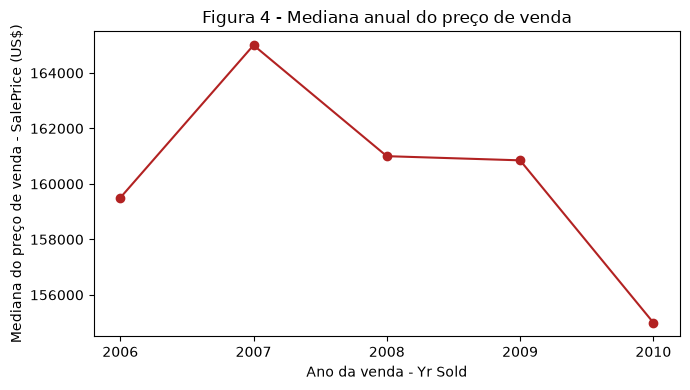

Mo Sold
1     122
2     133
3     232
4     279
5     395
6     505
7     449
8     233
9     161
10    171
11    143
12    104
Name: count, dtype: int64

In [7]:
# Tabela 8 - quantidade de vendas e mediana anual de preco_venda (SalePrice) por ano_venda (Yr Sold).
tabela_ano = (
    dados.groupby("Yr Sold")["SalePrice"]
    .agg(n_vendas="count", mediana_preco="median")
    .reset_index()
    .sort_values("Yr Sold")
)
display(tabela_ano)

# Figura 4 - mediana anual do preço de venda (anos em ordem cronológica; sem ligar imóveis individuais).
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    tabela_ano["Yr Sold"], tabela_ano["mediana_preco"], marker="o", color="firebrick"
)
ax.set_xlabel("Ano da venda - Yr Sold")
ax.set_ylabel("Mediana do preço de venda - SalePrice (US$)")
ax.set_title("Figura 4 - Mediana anual do preço de venda")
ax.set_xticks(tabela_ano["Yr Sold"])
fig.tight_layout()
plt.show()

# Extensão descritiva: quantidade de vendas por mes_venda (Mo Sold), sem substituir a agregação anual.
vendas_por_mes = dados["Mo Sold"].value_counts().sort_index()
display(vendas_por_mes)

# Interpretação: mediana oscila pouco entre 2006-2009 (~159-165 mil) e cai em 2010, ano com bem menos
# vendas na base (cobertura parcial do ano, não queda real de mercado). Diferenças entre anos podem
# refletir composição dos imóveis vendidos, inflação nominal e condições de mercado (ex.: crise de 2008),
# não uma tendência causal, trajetória de um mesmo imóvel, nem análise formal de série temporal.

#### 6.2 Preço de venda (`SalePrice`) e área construída (`Gr Liv Area`)

Para preço de venda (`SalePrice`) e área construída (`Gr Liv Area`):

- construir o diagrama de dispersão;
- examinar direção, forma, grupos e valores discrepantes;
- calcular a correlação linear de Pearson;
- interpretar intensidade e direção sem atribuir causalidade;
- indicar como valores discrepantes podem afetar o coeficiente.


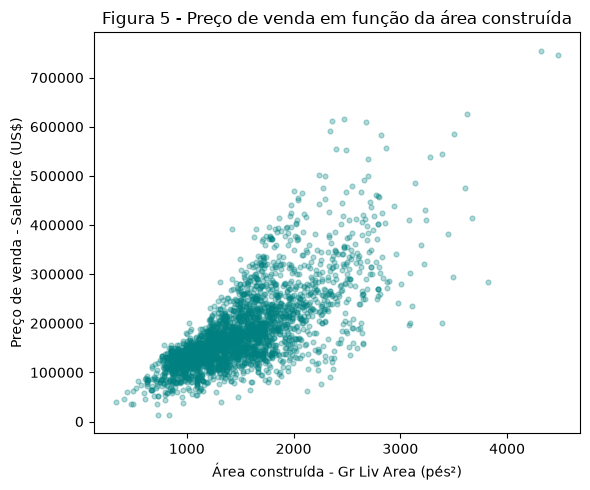

Correlação de Pearson (Gr Liv Area x SalePrice): 0.727


In [8]:
# Figura 5 - diagrama de dispersão entre area_construida (Gr Liv Area) e preco_venda (SalePrice).
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(dados["Gr Liv Area"], dados["SalePrice"], alpha=0.3, s=12, color="teal")
ax.set_xlabel("Área construída - Gr Liv Area (pés²)")
ax.set_ylabel("Preço de venda - SalePrice (US$)")
ax.set_title("Figura 5 - Preço de venda em função da área construída")
fig.tight_layout()
plt.show()

# Correlação linear de Pearson entre area_construida e preco_venda.
correlacao_pearson = dados["Gr Liv Area"].corr(dados["SalePrice"], method="pearson")
print(f"Correlação de Pearson (Gr Liv Area x SalePrice): {correlacao_pearson:.3f}")

# Interpretação: correlação positiva forte (~0,73) — imóveis maiores tendem a vender por preços mais
# altos —, sem implicar causalidade. Os 3 imóveis de venda parcial já excluídos na seção 4 tinham área
# muito alta e preço desproporcional a ela; mantê-los na base derrubaria o coeficiente para ~0,71,
# mostrando como um pequeno número de discrepantes pode enfraquecer a correlação medida.

#### 6.3 Preço de venda (`SalePrice`) e característica qualitativa $B$

Para preço de venda (`SalePrice`) e característica qualitativa $B$:

- apresentar uma tabela com quantidade, mediana, $Q_1$, $Q_3$ e $IQR$ do preço por categoria;
- construir boxplots do preço segundo as categorias de $B$;
- interpretar diferenças de posição, dispersão e valores discrepantes;
- não realizar inferência nem atribuir causalidade às diferenças observadas.


,n,mediana,Q1,Q3,IQR
acabamento_garagem,,,,,
Acabada,725,215000.0,174190.0,286000.0,111810.0
Parcialmente acabada,812,190000.0,155000.0,233185.0,78185.0
Inacabada,1231,135000.0,116000.0,157250.0,41250.0
Sem garagem,157,100000.0,82000.0,127500.0,45500.0


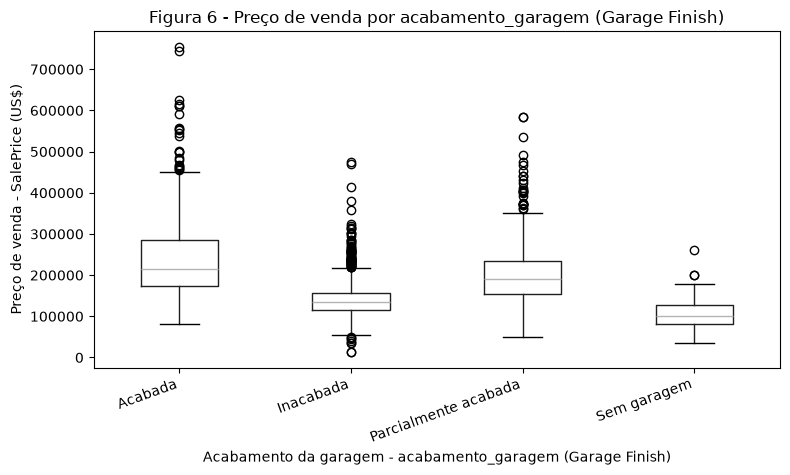

In [9]:
# Tabela 9 - quantidade, mediana, Q1, Q3 e IQR de preco_venda por categoria de acabamento_garagem.
resumo_por_categoria = dados.groupby("acabamento_garagem", observed=True)[
    "SalePrice"
].agg(
    n="count",
    mediana="median",
    Q1=lambda s: s.quantile(0.25),
    Q3=lambda s: s.quantile(0.75),
)
resumo_por_categoria["IQR"] = resumo_por_categoria["Q3"] - resumo_por_categoria["Q1"]
resumo_por_categoria = resumo_por_categoria.sort_values("mediana", ascending=False)
display(resumo_por_categoria)

# Figura 6 - boxplots de preco_venda segundo as categorias de acabamento_garagem (Garage Finish).
fig, ax = plt.subplots(figsize=(8, 5))
dados.boxplot(column="SalePrice", by="acabamento_garagem", ax=ax, grid=False)
ax.set_xlabel("Acabamento da garagem - acabamento_garagem (Garage Finish)")
ax.set_ylabel("Preço de venda - SalePrice (US$)")
ax.set_title("Figura 6 - Preço de venda por acabamento_garagem (Garage Finish)")
plt.suptitle("")
plt.xticks(rotation=20, ha="right")
fig.tight_layout()
plt.show()

# Interpretação: mediana cai na ordem Acabada > Parcialmente acabada > Inacabada > Sem garagem, e a
# dispersão (IQR) é bem maior em Acabada que nas demais — associação entre acabamento_garagem e preço,
# não causalidade, já que a categoria provavelmente reflete outras características do imóvel (tamanho,
# padrão construtivo) que também elevam o preço. Há discrepantes superiores em quase todas as categorias.

### 7. Exportação do dado pré-processado

O notebook deverá encerrar com um registro explícito de:

- nomes originais e nomes utilizados;
- tratamentos realizados;
- agrupamento final de $B$;
- rótulos finais das categorias de $B$;
- mapeamento dos nomes originais, incluindo `SalePrice`, `Gr Liv Area`, `Yr Sold` e, se utilizado, `Mo Sold`;
- caminho ou procedimento para reproduzir a versão organizada;
- arquivo processado `data/processed/AmesHousing.csv`.


In [10]:
# Tabela 10 - registro das transformações e justificativas aplicadas sobre a cópia de trabalho.
registro_tratamentos = pd.DataFrame(
    [
        {
            "problema": "Cópia bruta preservada",
            "regra_aplicada": "df mantido intacto; transformações aplicadas apenas em dados",
            "registros_afetados": len(df),
            "decisao": "Preservar df como referência bruta",
        },
        {
            "problema": "Mas Vnr Area ausente",
            "regra_aplicada": "Ausências não convertidas em 0 nem em 'sem revestimento'",
            "registros_afetados": int(df["Mas Vnr Area"].isna().sum()),
            "decisao": "Manter como ausente",
        },
        {
            "problema": "Vendas parciais com área > 4000 pés²",
            "regra_aplicada": "Exclusão contextual documentada (De Cock, 2011), não automática por IQR",
            "registros_afetados": len(df) - len(dados),
            "decisao": "Excluir da base de trabalho",
        },
        {
            "problema": "Garage Finish ausente sem garagem (Garage Type também ausente)",
            "regra_aplicada": "Recodificado como categoria válida 'Sem garagem', conforme dicionário de dados",
            "registros_afetados": int(
                (df["Garage Finish"].isna() & df["Garage Type"].isna()).sum()
            ),
            "decisao": "Recodificar como categoria",
        },
        {
            "problema": "Garage Finish ausente com garagem existente (Garage Type preenchido)",
            "regra_aplicada": "Não classificado em nenhuma categoria; distinto de 'sem garagem'",
            "registros_afetados": int(
                (df["Garage Finish"].isna() & df["Garage Type"].notna()).sum()
            ),
            "decisao": "Manter como ausente",
        },
        {
            "problema": "Categorias de acabamento_garagem (Garage Finish)",
            "regra_aplicada": "Todas as categorias com n >= 150 observações",
            "registros_afetados": int(dados["acabamento_garagem"].notna().sum()),
            "decisao": "Rotular sem agrupar categorias",
        },
    ]
)
display(registro_tratamentos)

# Mapeamento dos nomes originais para reprodução da versão organizada.
mapa_exportacao = {
    "preco_venda": "SalePrice",
    "area_construida": "Gr Liv Area",
    "ano_venda": "Yr Sold",
    "mes_venda": "Mo Sold",
    "acabamento_garagem": "Garage Finish",
}
print("Mapeamento nome_legivel (nome_original) usado na exportação:")
for legivel, original in mapa_exportacao.items():
    print(f"  {legivel} ({original})")

# Procedimento de reprodução e exportação do dado pré-processado.
os.makedirs("data/processed", exist_ok=True)
caminho_processado = "data/processed/AmesHousing.csv"
dados.to_csv(caminho_processado, index=False)
print(
    f"Base pré-processada exportada para '{caminho_processado}': "
    f"{dados.shape[0]} linhas x {dados.shape[1]} colunas."
)
print(
    "Reprodução: executar este notebook (ap1.ipynb) integralmente a partir de data/raw/AmesHousing.csv."
)

,problema,regra_aplicada,registros_afetados,decisao
0,Cópia bruta preservada,df mantido intacto; transformações aplicadas a...,2930,Preservar df como referência bruta
1,Mas Vnr Area ausente,Ausências não convertidas em 0 nem em 'sem rev...,23,Manter como ausente
2,Vendas parciais com área > 4000 pés²,"Exclusão contextual documentada (De Cock, 2011...",3,Excluir da base de trabalho
3,Garage Finish ausente sem garagem (Garage Type...,Recodificado como categoria válida 'Sem garage...,157,Recodificar como categoria
4,Garage Finish ausente com garagem existente (G...,Não classificado em nenhuma categoria; distint...,2,Manter como ausente
5,Categorias de acabamento_garagem (Garage Finish),Todas as categorias com n >= 150 observações,2925,Rotular sem agrupar categorias


Mapeamento nome_legivel (nome_original) usado na exportação:
  preco_venda (SalePrice)
  area_construida (Gr Liv Area)
  ano_venda (Yr Sold)
  mes_venda (Mo Sold)
  acabamento_garagem (Garage Finish)
Base pré-processada exportada para 'data/processed/AmesHousing.csv': 2927 linhas x 83 colunas.
Reprodução: executar este notebook (ap1.ipynb) integralmente a partir de data/raw/AmesHousing.csv.


## Limitações mínimas

Discutir:

- natureza observacional dos dados;
- período e local abrangidos;
- limites de representatividade;
- efeito potencial das decisões de preparação;
- diferença entre valor discrepante e erro.
- diferença entre associação e causalidade.


In [11]:
# Natureza observacional: os dados vêm de vendas reais, não de um experimento controlado; não há
# atribuição aleatória de características aos imóveis, então relações encontradas são associações.
# Período e local: vendas registradas em Ames, Iowa (EUA), entre 2006 e 2010; conclusões não se estendem
# a outras cidades, países ou períodos (ex.: outro ciclo econômico).
# Representatividade: a amostra cobre só imóveis residenciais vendidos nesse período/local; imóveis não
# vendidos, comerciais ou de outras regiões não estão representados.
# Efeito das decisões de preparação: manter ausentes em Mas Vnr Area e Garage Finish (quando há garagem)
# reduz o n de análises que usarem essas colunas; excluir os 3 imóveis de venda parcial evita distorcer a
# relação área-preço, mas também reduz um pouco a variabilidade observada de área/preço.
# Discrepante x erro: um valor discrepante (ex.: área muito grande) pode ser um dado real, só incomum;
# erro seria um valor logicamente impossível ou mal registrado (ex.: área negativa) — os discrepantes
# aqui foram tratados como reais, exceto os 3 casos de venda parcial, cujo preço não reflete o imóvel.
# Associação x causalidade: todas as relações discutidas (ano, área, acabamento_garagem com preço) são
# associações estatísticas; nenhuma foi testada nem interpretada como relação de causa e efeito.